Copyright © 2026 [Giovanni Squillero](https://squillero.github.io/) / [Politecnico di Torino](https://www.polito.it)  
[`https://github.com/squillero/computational-intelligence`](https://github.com/squillero/computational-intelligence)  
Free under certain conditions — see the [`license`](https://github.com/squillero/computational-intelligence/blob/master/LICENSE) for details.  

In [1]:
from itertools import chain, combinations, product
from collections import deque, abc
from math import inf

from icecream import ic

In [2]:
# VISUALIZATION

import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 6)


def draw_space(G):
    if "layout" not in G.graph:
        G.graph["layout"] = nx.random_layout(G)

    nx.draw(
        G,
        # arrows=False,
        # arrowsize=15,
        pos=G.graph["layout"],
        node_color=[c for _, c in G.nodes(data="c")],
        node_size=[G.nodes[n]["s"] for n in G.nodes],
        width=[G[u][v]["w"] for u, v in G.edges()],
        edge_color=[G[u][v]["c"] for u, v in G.edges()],
    )

In [3]:
# Defs and utility functions

ALL = "ABC"
BOAT_SIZE = 2


# Brothers: A, B, C...
def brother(x: str) -> str:
    return x.upper()


# Sisters: a, b, c...
def sister(x: str) -> str:
    return x.lower()

In [4]:
# The "state"

from typing import NamedTuple  # typed successor of namedtuple


class State(NamedTuple):
    left: frozenset
    boat: str


# No need to explicitly save who's on the right bank of the river
def make_right(group: abc.Set[str]) -> frozenset[str]:
    return frozenset(set(brother(ALL) + sister(ALL)) - group)

In [5]:
# Constraints

# No woman can be in the company of another man unless her brother is also present
def is_valid_group(group: abc.Set[str]) -> bool:
    for x in ALL:
        if sister(x) in group and brother(x) not in group and set(brother(ALL)) & group:
            return False
    return True


# Valid state? We need to check both banks
def is_valid_state(state: State) -> bool:
    left = state.left
    right = make_right(left)
    return is_valid_group(left) and is_valid_group(right)


# I sthere a valid trip from state s1 to state s2?
def is_trip_possible(s1: State, s2: State) -> bool:
    if s1.boat == s2.boat:
        # Boat did not change side
        return False
    if s1.boat == "L":
        # Boat is moving from left bank to the right bank
        if not s2.left < s1.left:
            # But the people on the left bank after the crossing is not a subset of the original ones
            return False
        boat = s1.left - s2.left
    else:
        # Boat is moving from right bank to the left bank
        if not s1.left < s2.left:
            # Same as above, but for the right bank (s1 and s2 are swapped)
            return False
        boat = s2.left - s1.left

    if not 1 <= len(boat) <= BOAT_SIZE:
        return False

    return is_valid_group(boat)

## State space

In [6]:
state_space = set()
for brothers, sisters, boat in product(
    chain.from_iterable(combinations(brother(ALL), r) for r in range(1 + len(ALL))),
    chain.from_iterable(combinations(sister(ALL), r) for r in range(1 + len(ALL))),
    "RL",
):
    state = State(left=frozenset(brothers + sisters), boat=boat)
    state_space.add(state)

### Visualization

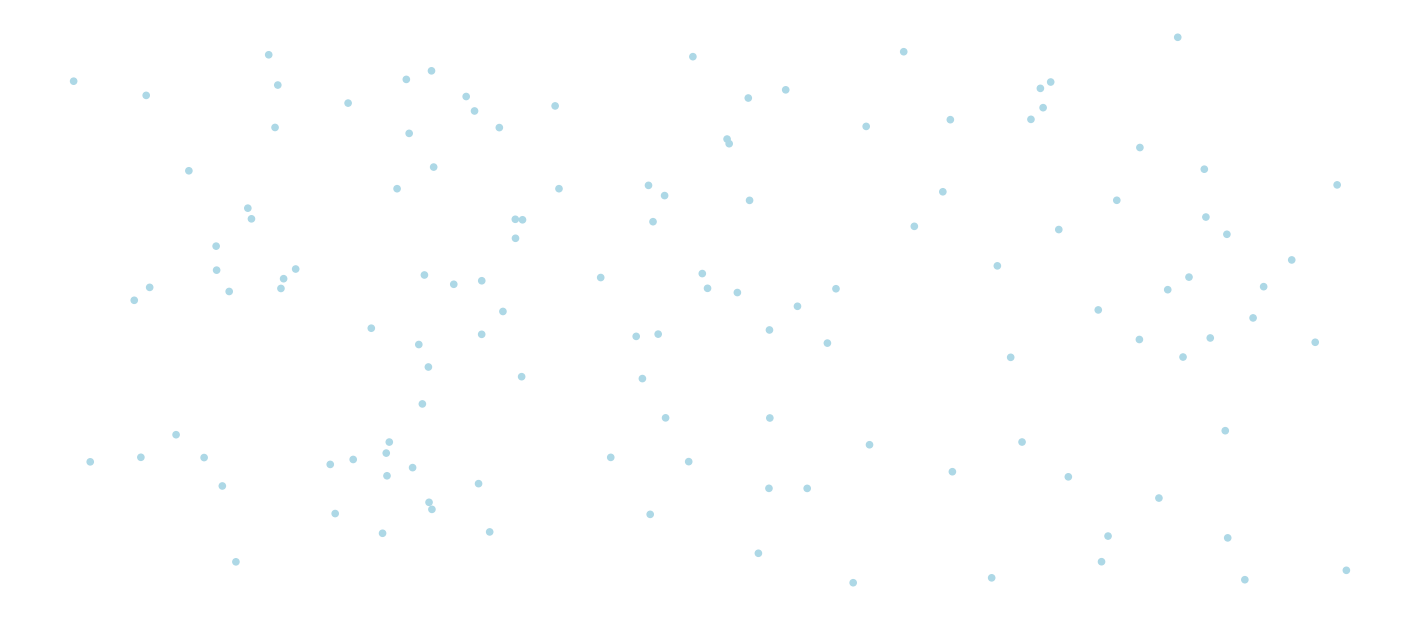

In [7]:
# Visualization

G = nx.DiGraph()
for s in state_space:
    G.add_node(s, c="lightblue", s=20)
draw_space(G)

## Solution space

In [8]:
solution_space = set()
for state in state_space:
    if is_valid_state(state):
        solution_space.add(state)

### Visualization

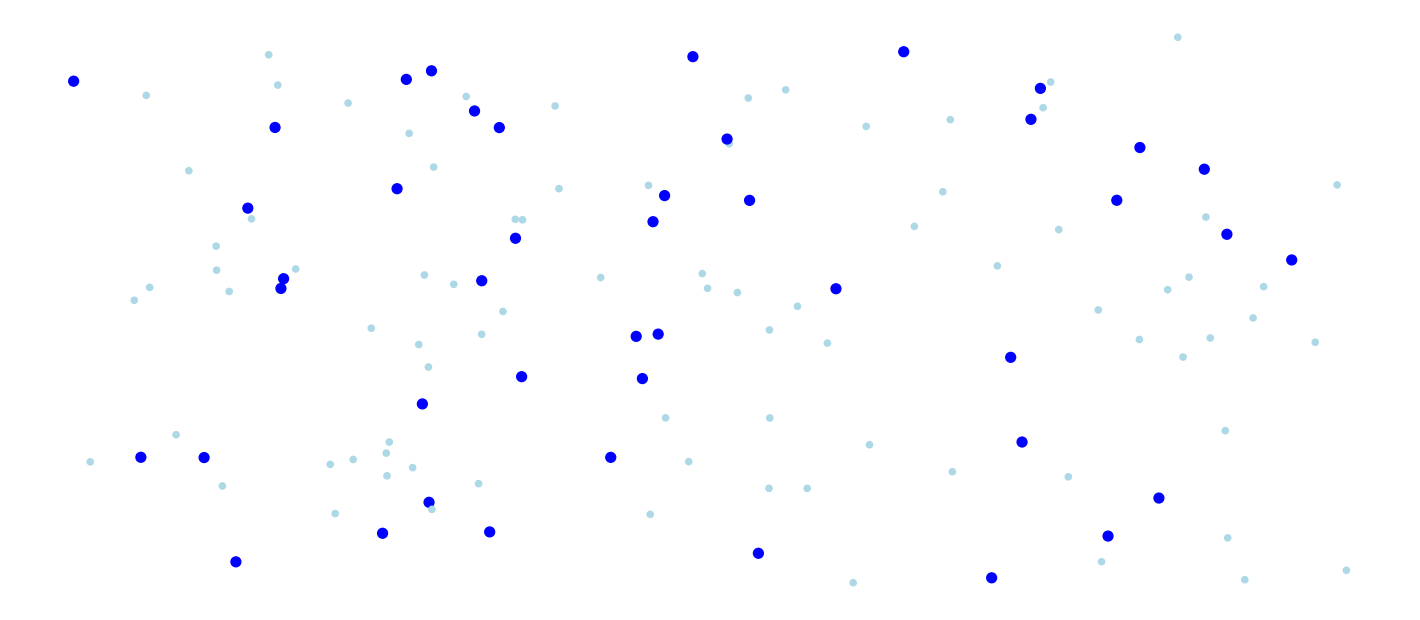

In [9]:
for s in solution_space:
    G.nodes[s]["c"] = "blue"
    G.nodes[s]["s"] = 50
draw_space(G)

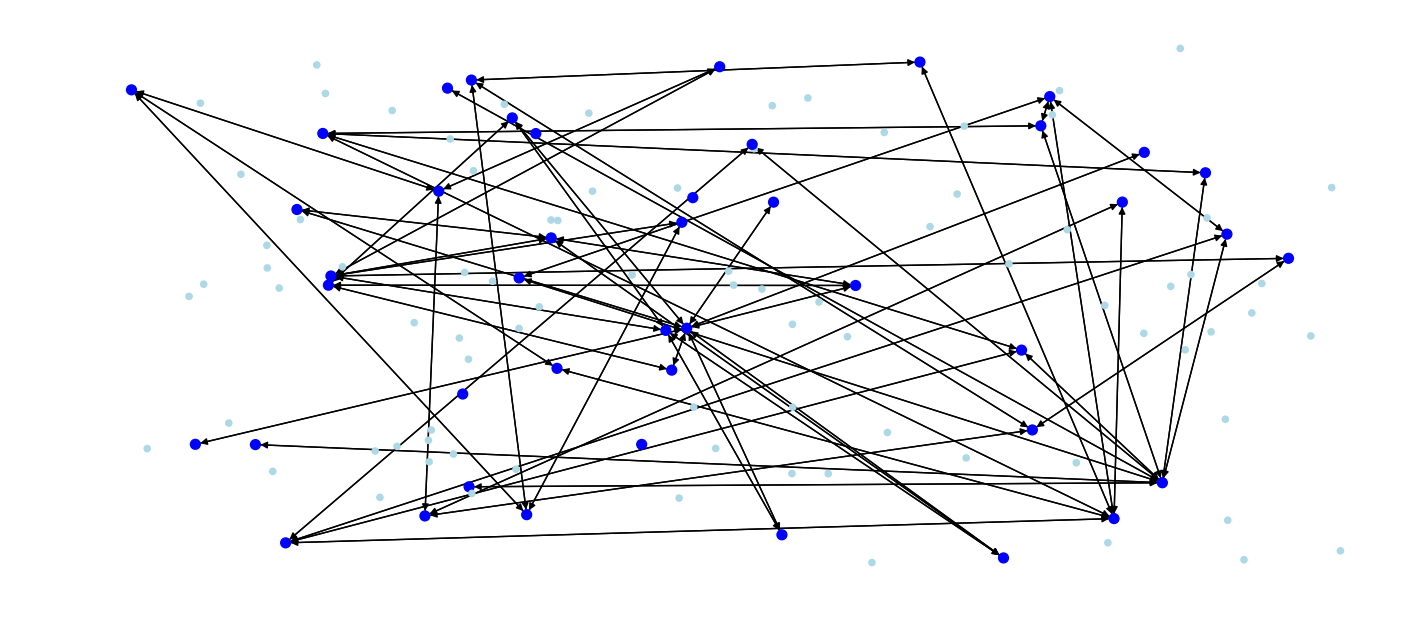

In [10]:
for s1, s2 in product(solution_space, repeat=2):
    if is_trip_possible(s1, s2):
        G.add_edge(s1, s2, c="black", w=1)
draw_space(G)

ic| n: State(left=frozenset(), boat='L')
ic| n: State(left=frozenset({'A', 'B', 'b', 'C', 'a', 'c'}), boat='R')
ic| n: State(left=frozenset({'a', 'c', 'b'}), boat='R')
ic| n: State(left=frozenset({'C', 'A', 'B'}), boat='L')


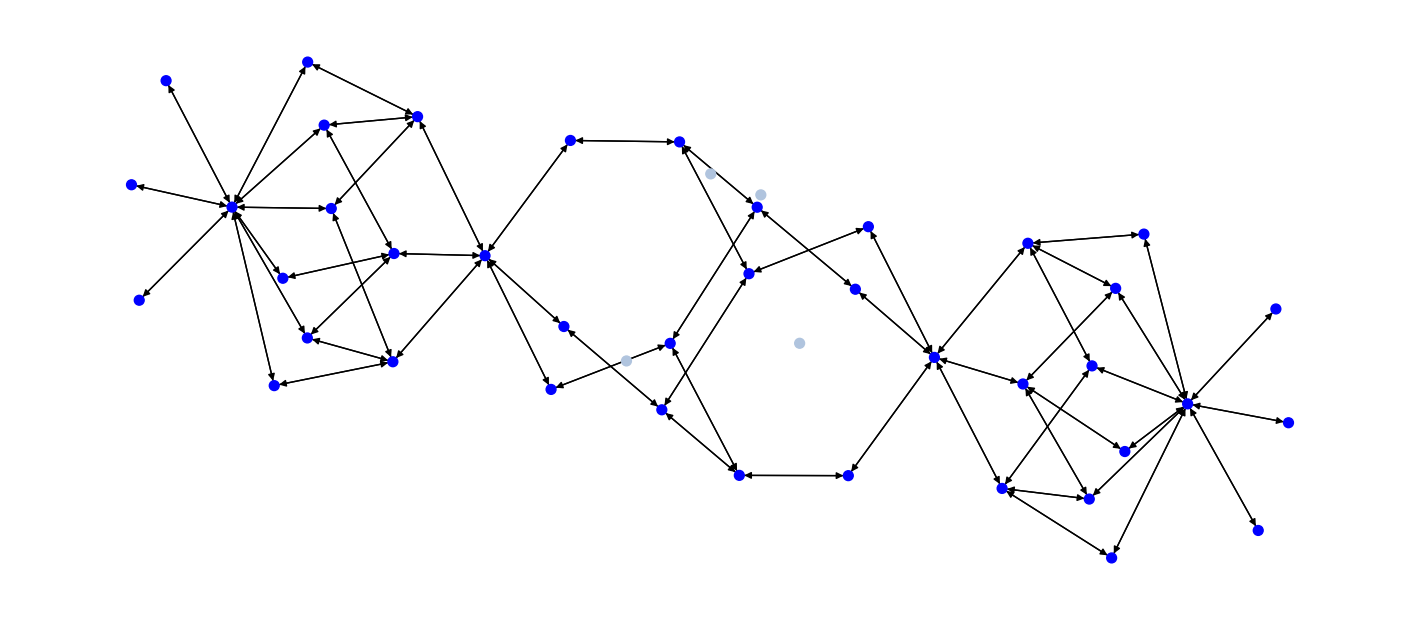

In [11]:
G.remove_nodes_from(list(state_space - solution_space))
for n in G:
    if G.degree(n) == 0:
        ic(n)
        G.nodes[n]["c"] = "lightsteelblue"
G.graph["layout"] = nx.kamada_kawai_layout(G)
draw_space(G)

In [12]:
# BFS, ca va sans dire
def bfs(solutions_space, source, destination) -> list[State]:
    frontier = deque([source], maxlen=len(solutions_space))
    parent = {source: list()}

    frontier.append(source)
    while (state := frontier.popleft()) != destination:
        reachable_states = (s for s in solutions_space if is_trip_possible(state, s))
        for s in reachable_states:
            if s not in parent:
                frontier.append(s)
                parent[s] = parent[state] + [state]
    assert destination in parent, "No solution"
    return parent[destination] + [destination]

In [13]:
path = bfs(
    solution_space,
    State(left=frozenset(brother(ALL) + sister(ALL)), boat="L"),
    State(left=frozenset(), boat="R"),
)

### Visualization

ic| trip: 1, banks: 'ABCabc ||| ', boat: ' bc▶'
ic| trip: 2, banks: 'ABCa ||| bc', boat: '◀b '
ic| trip: 3, banks: 'ABCab ||| c', boat: ' ab▶'
ic| trip: 4, banks: 'ABC ||| abc', boat: '◀a '
ic| trip: 5, banks: 'ABCa ||| bc', boat: ' BC▶'
ic| trip: 6, banks: 'Aa ||| BCbc', boat: '◀Cc '
ic| trip: 7, banks: 'ACac ||| Bb', boat: ' AC▶'
ic| trip: 8, banks: 'ac ||| ABCb', boat: '◀b '
ic| trip: 9, banks: 'abc ||| ABC', boat: ' ac▶'
ic| trip: 10, banks: 'b ||| ABCac', boat: '◀c '
ic| trip: 11, banks: 'bc ||| ABCa', boat: ' bc▶'


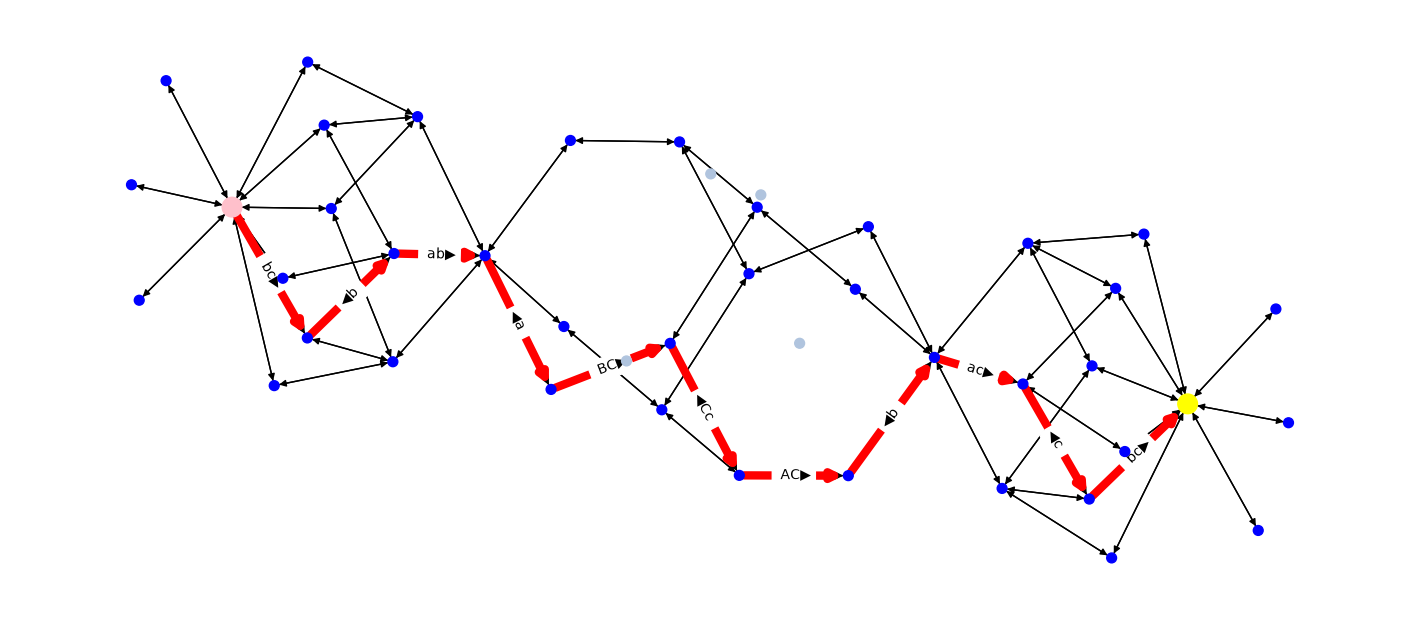

In [14]:
start = State(left=frozenset(brother(ALL) + sister(ALL)), boat="L")
G.nodes[start]["c"] = "pink"
G.nodes[start]["s"] = 200
end = State(left=frozenset(), boat="R")
G.nodes[end]["c"] = "yellow"
G.nodes[end]["s"] = 200
draw_space(G)

R = " ▶"
L = "◀ "
trip = 1
visual_path = list()
labels = dict()
for s1, s2 in zip(path, path[1:]):
    boat = L[trip % 2]+ "".join(sorted(s1.left ^ s2.left)) + R[trip % 2]
    banks = "".join(sorted(s1.left)) + " ||| " + "".join(sorted(make_right(s1.left)))
    ic(trip, banks, boat)
    trip += 1
    visual_path.append((s1, s2) for s1, s2 in zip(path[::-1], path[-2::-1]))
    labels[s1, s2] = boat

nx.draw_networkx_edges(
    G,
    G.graph["layout"],
    node_size=[G.nodes[n]["s"] for n in G.nodes],
    edgelist=[(s2, s1) for s1, s2 in zip(path[::-1], path[-2::-1])],
    arrows=True,
    width=6,
    arrowsize=12,
    edge_color="red",
)
nx.draw_networkx_edge_labels(
    G,
    G.graph["layout"],
    node_size=[G.nodes[n]["s"] for n in G.nodes],
    edge_labels=labels,
)
None  # prevent last display